In [2]:
# Reload other .py files without having to restart the kernel
%load_ext autoreload
%autoreload 2

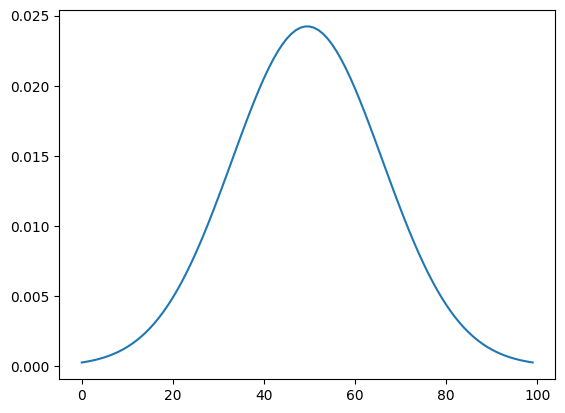

In [3]:
from torch.distributions import normal
import torch
import matplotlib.pyplot as plt

N = 100
myNorm = normal.Normal(0, 1)
targets = torch.linspace(-3, 3, N)

samples = myNorm.log_prob(targets).exp()
samples /= samples.sum()

plt.plot(samples)
plt.show()

c:\Users\Nicholas\anaconda3\envs\ComputerVision\Lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


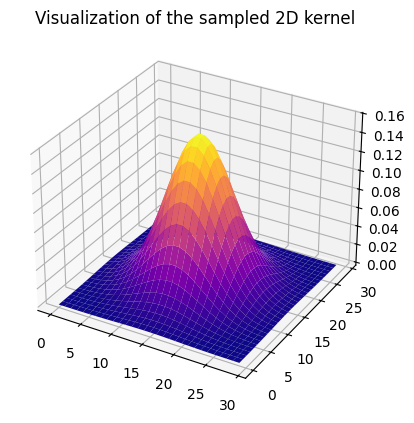

In [4]:
kernel_size = 30
distribution = normal.Normal(loc=0, scale=1)
gaussianFilter2d = distribution.log_prob(torch.linspace(-3, 3, kernel_size)).exp()
gaussianFilter2d = gaussianFilter2d[:, None] * gaussianFilter2d[None, :]

coords = torch.meshgrid(
    torch.arange(kernel_size),
    torch.arange(kernel_size)
)

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot_surface(coords[0], coords[1], gaussianFilter2d, cmap='plasma')
plt.title('Visualization of the sampled 2D kernel')
plt.show()

In [ ]:
from K2.Blocks import BlurPool

H = torch.arange(16, 64, 3)
K = torch.arange(1, 5)

randomTensor = torch.randn((16, 3, 19, 19))
layer = BlurPool(
    out_channels=3,
    stride=2,
    kernel_size=3
)
output = layer(randomTensor)
print(randomTensor.shape)
print(output.shape)

# Sandbox for testing blocks
# for h in H:
#     for k in K:
#         randomTensor = torch.randn((16, 3, h, h))
        
#         # layer = ResidualBlock(in_channels=3, kernel_size=3)
#         # layer = ResidualBlockVersatile(
#         #     in_channels=3,
#         #     out_channels=32
#         # )
#         # layer = DepthwiseSeparableConv2d(
#         #     in_channels=3, 
#         #     out_channels=16,
#         #     kernel_size=3,
#         #     stride=2
#         # )
        
#         layer = BlurPool(
#             out_channels=3,
#             stride=2,
#             kernel_size=k
#         )

#         output = layer(randomTensor).shape
#         # (16, 16) -> (8, 8) which is correct
#         # (19, 19) -> (10, 10)??? Shouldn't it go to (9, 9) if we floor first?
#         # Internal shape goes to (21, 21) after padding which is then strided to (10, 10)
#         print(f'Input Shape: {randomTensor.shape}')
#         print(f'Output Shape: {output}')
#         print(f'Kernel size: {k}')
#         print()


torch.Size([16, 3, 19, 19])
torch.Size([16, 3, 10, 10])
